**SWE-Bench tokens with document replay (Codex / gpt-5.6-luna).** Left
column is session tokens only. Right column charges session plus the
document-replay tokens that optimistic checkpoint and whole-branch
abort pay on every task. Scale bins are terciles of the clean-solve
cost (100 tasks). Repositories are ordered by task count. Line styles
match the earlier FAST figures.


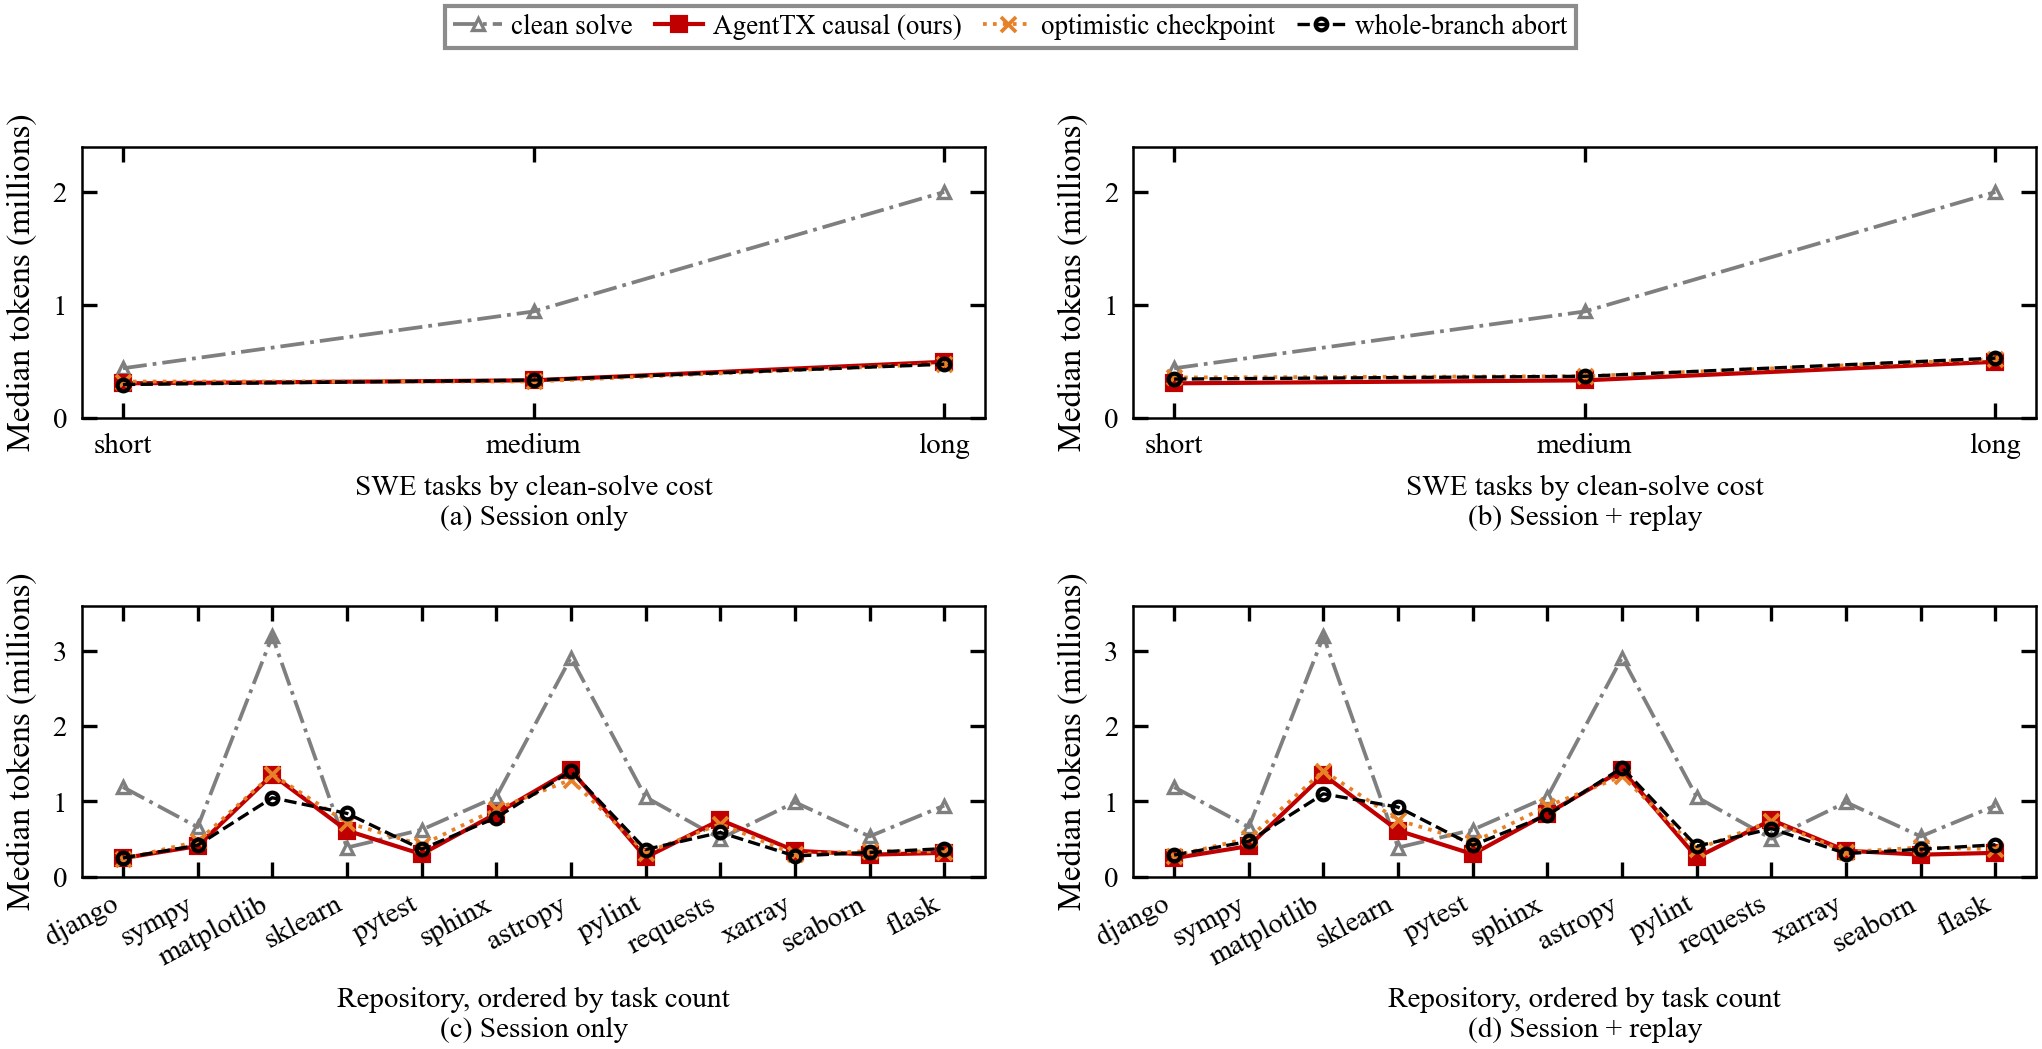

In [1]:
# ipython -c "%run plot_swe_tokens.ipynb"
# FAST/USENIX line-plot conventions: white panels, boxed top legend,
# red solid squares = ours. Token y-values are charged = session + replay.
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

try:
    get_ipython()
except NameError:
    matplotlib.use("Agg")

STANDARD_WIDTH = 17.8


def cm_to_inch(value):
    return value / 2.54


plt.rcParams.update(plt.rcParamsDefault)
matplotlib.rcParams["text.usetex"] = False
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Nimbus Roman", "Times New Roman", "Times"]
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.linewidth"] = 0.6
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["legend.frameon"] = True
plt.rcParams["legend.edgecolor"] = "0.55"
plt.rcParams["legend.framealpha"] = 1.0
plt.rcParams["legend.fancybox"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

STYLES = {
    "no_fault": dict(
        color="#7f7f7f",
        marker="^",
        linestyle="-.",
        linewidth=0.9,
        markersize=3.0,
        markerfacecolor="none",
        markeredgewidth=0.8,
    ),
    "causal": dict(color="#c00000", marker="s", linestyle="-", linewidth=1.0, markersize=3.2),
    "temporal_checkpoint": dict(
        color="#e78129",
        marker="x",
        linestyle=":",
        linewidth=0.9,
        markersize=3.6,
        markeredgewidth=0.9,
    ),
    "whole_branch_abort": dict(
        color="black",
        marker="o",
        linestyle="--",
        linewidth=0.8,
        markersize=2.8,
        markerfacecolor="none",
    ),
}
LABELS = {
    "no_fault": "clean solve",
    "causal": "AgentTX causal (ours)",
    "temporal_checkpoint": "optimistic checkpoint",
    "whole_branch_abort": "whole-branch abort",
}
MODES = list(STYLES)

cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "motivation" else cwd
FIGDIR = ROOT / "motivation"
PAPER = ROOT / "paper" / "img"
FIGDIR.mkdir(parents=True, exist_ok=True)
PAPER.mkdir(parents=True, exist_ok=True)
CSV = ROOT / "experiments" / "results" / "codex_7mode_full_r1_parallel_20260903" / "swe_official_tasks_raw.csv"

df = pd.read_csv(CSV)
df["total_tokens"] = pd.to_numeric(df["total_tokens"], errors="coerce").fillna(0.0)
df["doc_replay_tokens"] = pd.to_numeric(df["doc_replay_tokens"], errors="coerce").fillna(0.0)
df["charged"] = df["total_tokens"] + df["doc_replay_tokens"]
df["repo_short"] = df["repo"].astype(str).str.split("/").str[-1]
df.loc[df["repo_short"] == "scikit-learn", "repo_short"] = "sklearn"

SCALE_LABELS = ["short", "medium", "long"]
REPO_ORDER = (
    df.groupby("repo_short")["task"].nunique().sort_values(ascending=False).index.tolist()
)
sx = np.arange(len(SCALE_LABELS))
rx = np.arange(len(REPO_ORDER))

sess = df.pivot_table(index=["task", "repo_short"], columns="mode", values="total_tokens", aggfunc="first")
charged = df.pivot_table(index=["task", "repo_short"], columns="mode", values="charged", aggfunc="first")
nf = charged["no_fault"].reset_index(level=1, drop=True)
scale = pd.qcut(nf, 3, labels=SCALE_LABELS)


def scale_median(frame, mode):
    series = frame[mode].reset_index(level=1, drop=True)
    return [series[scale == label].median() for label in SCALE_LABELS]


def repo_median(frame, mode):
    return [
        frame.xs(repo, level=1)[mode].median() if repo in frame.index.get_level_values(1) else np.nan
        for repo in REPO_ORDER
    ]


fig = plt.figure(dpi=300, figsize=(cm_to_inch(STANDARD_WIDTH), cm_to_inch(8.8)))
handles = []

ax = plt.subplot(2, 2, 1)
for mode in MODES:
    handle, = ax.plot(sx, np.asarray(scale_median(sess, mode), dtype=float) / 1e6, **STYLES[mode], label=LABELS[mode])
    handles.append(handle)
ax.set_xticks(sx, SCALE_LABELS)
ax.set_ylim(0, 2.4)
ax.set_ylabel("Median tokens (millions)", fontsize=8)
ax.set_xlabel("SWE tasks by clean-solve cost\n(a) Session only", fontsize=7)

ax = plt.subplot(2, 2, 2)
for mode in MODES:
    ax.plot(sx, np.asarray(scale_median(charged, mode), dtype=float) / 1e6, **STYLES[mode])
ax.set_xticks(sx, SCALE_LABELS)
ax.set_ylim(0, 2.4)
ax.set_ylabel("Median tokens (millions)", fontsize=8)
ax.set_xlabel("SWE tasks by clean-solve cost\n(b) Session + replay", fontsize=7)

ax = plt.subplot(2, 2, 3)
for mode in MODES:
    ax.plot(rx, np.asarray(repo_median(sess, mode), dtype=float) / 1e6, **STYLES[mode])
ax.set_xticks(rx, REPO_ORDER, rotation=28, ha="right")
ax.set_ylim(0, 3.6)
ax.set_ylabel("Median tokens (millions)", fontsize=8)
ax.set_xlabel("Repository, ordered by task count\n(c) Session only", fontsize=7)

ax = plt.subplot(2, 2, 4)
for mode in MODES:
    ax.plot(rx, np.asarray(repo_median(charged, mode), dtype=float) / 1e6, **STYLES[mode])
ax.set_xticks(rx, REPO_ORDER, rotation=28, ha="right")
ax.set_ylim(0, 3.6)
ax.set_ylabel("Median tokens (millions)", fontsize=8)
ax.set_xlabel("Repository, ordered by task count\n(d) Session + replay", fontsize=7)

for axis in fig.axes:
    axis.tick_params(axis="both", labelsize=7, direction="in", top=True, right=True)

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.035),
    ncol=4,
    fontsize=6.5,
    columnspacing=0.8,
    handlelength=1.8,
    handletextpad=0.35,
    borderpad=0.3,
)
plt.tight_layout(pad=0.6, h_pad=1.8, w_pad=1.2, rect=[0.0, 0.0, 1.0, 0.91])
for dest in (FIGDIR, PAPER):
    fig.savefig(dest / "FIG-SWE-Tokens.pdf", bbox_inches="tight", pad_inches=0.02)
    fig.savefig(dest / "FIG-SWE-Token-Tasks.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
if matplotlib.get_backend().lower() != "agg":
    plt.show()

print(f"loaded {CSV}")
print("session vs session+replay by scale (millions)")
for kind, frame in [("session", sess), ("charged", charged)]:
    print(kind, {label: {mode: round(scale_median(frame, mode)[i] / 1e6, 3) for mode in MODES} for i, label in enumerate(SCALE_LABELS)})
print("django session", {mode: round(repo_median(sess, mode)[0] / 1e3, 1) for mode in MODES})
print("django charged", {mode: round(repo_median(charged, mode)[0] / 1e3, 1) for mode in MODES})
